# Tile ozone mean and ETOPO relief check

Region: latitude -3 to 2, longitude 121 to 131.  The default tile layout is 2 rows x 4 columns, matching the lower-right block of the 4x8 pure-space nugget map for lat -3..7 / lon 111..131.

This notebook does three things:

1. scans July 2022-2025 GEMS TCO files and computes tile-level mean ozone;
2. plots annual tile ozone means and simple 2022-2025 tile trends over a land/sea background;
3. downloads/uses NOAA ETOPO 2022 relief data for the same tiles and plots elevation/bathymetry plus land fraction.

Elevation source: NOAA/NCEI ETOPO 2022 15 arc-second Global Relief Model.  NOAA describes it as a global relief model integrating topography, bathymetry, and shoreline data; it is available through ETOPO 2022 NetCDF/ERDDAP access.

Useful source links:

- https://www.ncei.noaa.gov/products/etopo-global-relief-model
- https://coastwatch.pfeg.noaa.gov/erddap/griddap/ETOPO_2022_v1_15s.html


In [1]:

from pathlib import Path
import os

PROJECT_ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
GEMS_DATA_ROOT = Path('/Users/joonwonlee/Documents/GEMS_DATA')
PURE_SPACE_DIR = PROJECT_ROOT / 'GEMS_TCO_EDA' / 'pure_space'
OUT_DIR = PURE_SPACE_DIR / 'tile_o3_elevation_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Avoid matplotlib trying to write cache files outside this workspace.
os.environ.setdefault('MPLCONFIGDIR', str(PURE_SPACE_DIR / '.matplotlib_cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

YEARS = [2022, 2023, 2024, 2025]
MONTH = 7
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
NY, NX = 2, 4
NADIR_LON, NADIR_LAT = 128.0, 0.0

# Default source matches the regular-grid pure_space input.  Use 'csv_raw' if you want
# to recompute from raw expanded CSVs with FinalAlgorithmFlags filtering.
SOURCE_MODE = 'pickle_grid'  # 'pickle_grid' or 'csv_raw'
GOOD_FLAGS = {0.0, 2.0}
CSV_CHUNKSIZE = 1_000_000

# Native ETOPO is 15 arc-sec.  stride=12 gives 3 arc-min resolution, fast and detailed
# enough for tile context.  Lower it to 6 for denser relief if needed.
ETOPO_STRIDE = 12
ETOPO_CACHE = PURE_SPACE_DIR / 'etopo_2022_lat-3to2_lon121to131_stride12.csv'

print('output directory:', OUT_DIR)


output directory: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs


In [2]:

import pickle
from urllib.parse import quote

import numpy as np
import pandas as pd
import requests
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, TwoSlopeNorm
from scipy import stats

mpl.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 220,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
})

lat_edges = np.linspace(LAT_RANGE[0], LAT_RANGE[1], NY + 1)
lon_edges = np.linspace(LON_RANGE[0], LON_RANGE[1], NX + 1)
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])

print('lat_edges:', lat_edges)
print('lon_edges:', lon_edges)


lat_edges: [-3.  -0.5  2. ]
lon_edges: [121.  123.5 126.  128.5 131. ]


In [3]:

def tile_index(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    in_domain = (
        np.isfinite(lat)
        & np.isfinite(lon)
        & (lat >= LAT_RANGE[0])
        & (lat <= LAT_RANGE[1])
        & (lon >= LON_RANGE[0])
        & (lon <= LON_RANGE[1])
    )
    ty = np.searchsorted(lat_edges, lat, side='right') - 1
    tx = np.searchsorted(lon_edges, lon, side='right') - 1
    ty = np.clip(ty, 0, NY - 1).astype(np.int16)
    tx = np.clip(tx, 0, NX - 1).astype(np.int16)
    return in_domain, ty, tx


def empty_tile_accumulator(year):
    rows = []
    for ty in range(NY):
        for tx in range(NX):
            rows.append({
                'year': year,
                'tile_y': ty,
                'tile_x': tx,
                'tile_id': ty * NX + tx,
                'tile_lat_min': lat_edges[ty],
                'tile_lat_max': lat_edges[ty + 1],
                'tile_lon_min': lon_edges[tx],
                'tile_lon_max': lon_edges[tx + 1],
                'tile_lat_center': lat_centers[ty],
                'tile_lon_center': lon_centers[tx],
                'n': 0,
                'sum_o3': 0.0,
                'sumsq_o3': 0.0,
                'min_o3': np.inf,
                'max_o3': -np.inf,
            })
    return pd.DataFrame(rows)


def finalize_tile_accumulator(acc):
    acc = acc.copy()
    n = acc['n'].to_numpy(dtype=float)
    acc['mean_o3'] = np.where(n > 0, acc['sum_o3'] / n, np.nan)
    variance = np.where(n > 1, (acc['sumsq_o3'] - (acc['sum_o3'] ** 2) / n) / (n - 1), np.nan)
    acc['std_o3'] = np.sqrt(np.maximum(variance, 0.0))
    acc['min_o3'] = acc['min_o3'].replace([np.inf, -np.inf], np.nan)
    acc['max_o3'] = acc['max_o3'].replace([np.inf, -np.inf], np.nan)
    cols = [
        'year', 'tile_y', 'tile_x', 'tile_id',
        'tile_lat_min', 'tile_lat_max', 'tile_lon_min', 'tile_lon_max',
        'tile_lat_center', 'tile_lon_center',
        'n', 'mean_o3', 'std_o3', 'min_o3', 'max_o3',
        'sum_o3', 'sumsq_o3',
    ]
    return acc[cols]


def update_accumulator(acc, lat, lon, o3):
    in_domain, ty, tx = tile_index(lat, lon)
    o3 = np.asarray(o3, dtype=float)
    keep = in_domain & np.isfinite(o3)
    if not keep.any():
        return 0

    flat_id = ty[keep] * NX + tx[keep]
    values = o3[keep]
    for tile_id in np.unique(flat_id):
        vals = values[flat_id == tile_id]
        idx = acc.index[acc['tile_id'] == int(tile_id)][0]
        acc.loc[idx, 'n'] += int(vals.size)
        acc.loc[idx, 'sum_o3'] += float(vals.sum(dtype=np.float64))
        acc.loc[idx, 'sumsq_o3'] += float(np.square(vals, dtype=np.float64).sum())
        acc.loc[idx, 'min_o3'] = min(float(acc.loc[idx, 'min_o3']), float(vals.min()))
        acc.loc[idx, 'max_o3'] = max(float(acc.loc[idx, 'max_o3']), float(vals.max()))
    return int(keep.sum())


In [4]:

def pickle_grid_path(year):
    yy = str(year)[2:]
    return GEMS_DATA_ROOT / f'pickle_{year}' / f'tco_grid_lat-3to7_lon111to131_{yy}_{MONTH:02d}.pkl'


def expanded_csv_path(year):
    yy = str(year)[2:]
    return GEMS_DATA_ROOT / f'data_{year}' / f'data_{yy}_{MONTH:02d}_0131_N-37_E111131.csv'


def summarize_year_from_pickle_grid(year):
    path = pickle_grid_path(year)
    if not path.exists():
        raise FileNotFoundError(path)
    acc = empty_tile_accumulator(year)
    meta = {
        'year': year,
        'source_mode': 'pickle_grid',
        'source_path': str(path),
        'n_snapshots': 0,
        'rows_in_domain': 0,
    }
    with path.open('rb') as f:
        grid = pickle.load(f)
    meta['n_snapshots'] = len(grid)
    for i, (key, df) in enumerate(grid.items(), start=1):
        meta['rows_in_domain'] += update_accumulator(
            acc,
            df['Latitude'].to_numpy(),
            df['Longitude'].to_numpy(),
            df['ColumnAmountO3'].to_numpy(),
        )
        if i % 50 == 0 or i == len(grid):
            print(f'{year}: {i}/{len(grid)} snapshots processed')
    return finalize_tile_accumulator(acc), meta


def summarize_year_from_expanded_csv(year):
    path = expanded_csv_path(year)
    if not path.exists():
        raise FileNotFoundError(path)
    acc = empty_tile_accumulator(year)
    meta = {
        'year': year,
        'source_mode': 'csv_raw',
        'source_path': str(path),
        'n_chunks': 0,
        'rows_in_domain': 0,
        'good_finite_rows_in_domain': 0,
    }
    usecols = ['Latitude', 'Longitude', 'ColumnAmountO3', 'FinalAlgorithmFlags']
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CSV_CHUNKSIZE):
        meta['n_chunks'] += 1
        in_box = chunk['Latitude'].between(*LAT_RANGE) & chunk['Longitude'].between(*LON_RANGE)
        if not in_box.any():
            continue
        chunk = chunk.loc[in_box]
        meta['rows_in_domain'] += len(chunk)
        good = chunk['FinalAlgorithmFlags'].isin(GOOD_FLAGS).to_numpy()
        finite = np.isfinite(chunk['ColumnAmountO3'].to_numpy(dtype=float))
        chunk = chunk.loc[good & finite]
        meta['good_finite_rows_in_domain'] += len(chunk)
        if len(chunk):
            update_accumulator(
                acc,
                chunk['Latitude'].to_numpy(),
                chunk['Longitude'].to_numpy(),
                chunk['ColumnAmountO3'].to_numpy(),
            )
        if meta['n_chunks'] % 10 == 0:
            print(f'{year}: {meta["n_chunks"]} CSV chunks processed')
    return finalize_tile_accumulator(acc), meta


def summarize_all_years(source_mode=SOURCE_MODE):
    tile_tables = []
    metas = []
    for year in YEARS:
        print('\n---', year, source_mode, '---')
        if source_mode == 'pickle_grid':
            tile_df, meta = summarize_year_from_pickle_grid(year)
        elif source_mode == 'csv_raw':
            tile_df, meta = summarize_year_from_expanded_csv(year)
        else:
            raise ValueError(f'unknown source_mode: {source_mode}')
        tile_tables.append(tile_df)
        metas.append(meta)
    tile_summary = pd.concat(tile_tables, ignore_index=True)
    meta_df = pd.DataFrame(metas)
    return tile_summary, meta_df


In [5]:

summary_csv = OUT_DIR / f'tile_o3_mean_july_2022_2025_lat-3to2_lon121to131_{NY}x{NX}_{SOURCE_MODE}.csv'
meta_csv = OUT_DIR / f'tile_o3_mean_july_2022_2025_lat-3to2_lon121to131_{NY}x{NX}_{SOURCE_MODE}_meta.csv'

if summary_csv.exists() and meta_csv.exists():
    tile_o3 = pd.read_csv(summary_csv)
    run_meta = pd.read_csv(meta_csv)
    print('loaded cached ozone summary:', summary_csv)
else:
    tile_o3, run_meta = summarize_all_years(SOURCE_MODE)
    tile_o3.round(6).to_csv(summary_csv, index=False)
    run_meta.to_csv(meta_csv, index=False)
    print('saved:', summary_csv)
    print('saved:', meta_csv)

display(run_meta)
display(tile_o3[['year', 'tile_y', 'tile_x', 'n', 'mean_o3', 'std_o3', 'tile_lat_min', 'tile_lat_max', 'tile_lon_min', 'tile_lon_max']])


loaded cached ozone summary: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/tile_o3_mean_july_2022_2025_lat-3to2_lon121to131_2x4_pickle_grid.csv


,year,source_mode,source_path,n_snapshots,rows_in_domain
0,2022,pickle_grid,/Users/joonwonlee/Documents/GEMS_DATA/pickle_2...,240,4064645
1,2023,pickle_grid,/Users/joonwonlee/Documents/GEMS_DATA/pickle_2...,248,4336492
2,2024,pickle_grid,/Users/joonwonlee/Documents/GEMS_DATA/pickle_2...,248,4301695
3,2025,pickle_grid,/Users/joonwonlee/Documents/GEMS_DATA/pickle_2...,247,4320048


,year,tile_y,tile_x,n,mean_o3,std_o3,tile_lat_min,tile_lat_max,tile_lon_min,tile_lon_max
0,2022,0,0,486900,249.848500,4.682957,-3.0,-0.5,121.0,123.5
1,2022,0,1,502427,248.994575,4.633051,-3.0,-0.5,123.5,126.0
2,2022,0,2,504670,248.880607,5.015856,-3.0,-0.5,126.0,128.5
3,2022,0,3,511715,248.599903,4.976337,-3.0,-0.5,128.5,131.0
4,2022,1,0,514391,252.201344,4.612415,-0.5,2.0,121.0,123.5
5,2022,1,1,516448,252.171542,4.361154,-0.5,2.0,123.5,126.0
6,2022,1,2,513420,252.277925,4.745808,-0.5,2.0,126.0,128.5
7,2022,1,3,514674,251.944135,5.161212,-0.5,2.0,128.5,131.0
8,2023,0,0,523954,249.205059,4.656842,-3.0,-0.5,121.0,123.5
9,2023,0,1,548352,247.551782,4.313820,-3.0,-0.5,123.5,126.0


In [6]:

def etopo_download_url(stride=ETOPO_STRIDE):
    base = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/ETOPO_2022_v1_15s.csvp'
    query = f'z[({LAT_RANGE[0]}):{stride}:({LAT_RANGE[1]})][({LON_RANGE[0]}):{stride}:({LON_RANGE[1]})]'
    return base + '?' + quote(query, safe='[]():')


def load_or_download_etopo(cache_path=ETOPO_CACHE, stride=ETOPO_STRIDE):
    cache_path = Path(cache_path)
    if not cache_path.exists():
        url = etopo_download_url(stride)
        print('downloading:', url)
        response = requests.get(url, timeout=180)
        response.raise_for_status()
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        cache_path.write_bytes(response.content)
        print('saved:', cache_path)
    else:
        print('using cached ETOPO:', cache_path)
    elev = pd.read_csv(cache_path)
    rename = {}
    for col in elev.columns:
        if col.startswith('latitude'):
            rename[col] = 'latitude'
        elif col.startswith('longitude'):
            rename[col] = 'longitude'
    elev = elev.rename(columns=rename)
    elev['z'] = pd.to_numeric(elev['z'], errors='coerce')
    return elev.dropna(subset=['latitude', 'longitude', 'z']).copy()


def etopo_grid(elev):
    grid = elev.pivot(index='latitude', columns='longitude', values='z').sort_index().sort_index(axis=1)
    lats = grid.index.to_numpy(dtype=float)
    lons = grid.columns.to_numpy(dtype=float)
    lon2d, lat2d = np.meshgrid(lons, lats)
    return lon2d, lat2d, grid.to_numpy(dtype=float)


def summarize_etopo_by_tile(elev):
    in_domain, ty, tx = tile_index(elev['latitude'].to_numpy(), elev['longitude'].to_numpy())
    tmp = elev.loc[in_domain].copy()
    tmp['tile_y'] = ty[in_domain]
    tmp['tile_x'] = tx[in_domain]
    tmp['tile_id'] = tmp['tile_y'] * NX + tmp['tile_x']
    rows = []
    for tile_y in range(NY):
        for tile_x in range(NX):
            g = tmp[(tmp['tile_y'] == tile_y) & (tmp['tile_x'] == tile_x)]
            land = g[g['z'] > 0]
            rows.append({
                'tile_y': tile_y,
                'tile_x': tile_x,
                'tile_id': tile_y * NX + tile_x,
                'tile_lat_min': lat_edges[tile_y],
                'tile_lat_max': lat_edges[tile_y + 1],
                'tile_lon_min': lon_edges[tile_x],
                'tile_lon_max': lon_edges[tile_x + 1],
                'tile_lat_center': lat_centers[tile_y],
                'tile_lon_center': lon_centers[tile_x],
                'n_etopo': len(g),
                'mean_topobathy_m': float(g['z'].mean()) if len(g) else np.nan,
                'median_topobathy_m': float(g['z'].median()) if len(g) else np.nan,
                'min_topobathy_m': float(g['z'].min()) if len(g) else np.nan,
                'max_topobathy_m': float(g['z'].max()) if len(g) else np.nan,
                'land_fraction': float((g['z'] > 0).mean()) if len(g) else np.nan,
                'mean_land_elevation_m': float(land['z'].mean()) if len(land) else np.nan,
                'max_land_elevation_m': float(land['z'].max()) if len(land) else np.nan,
            })
    return pd.DataFrame(rows)

elev = load_or_download_etopo()
etopo_summary = summarize_etopo_by_tile(elev)
etopo_summary_csv = OUT_DIR / f'etopo_2022_tile_summary_lat-3to2_lon121to131_{NY}x{NX}_stride{ETOPO_STRIDE}.csv'
etopo_summary.round(4).to_csv(etopo_summary_csv, index=False)
print('saved:', etopo_summary_csv)
display(etopo_summary)


using cached ETOPO: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/etopo_2022_lat-3to2_lon121to131_stride12.csv
saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/etopo_2022_tile_summary_lat-3to2_lon121to131_2x4_stride12.csv


,tile_y,tile_x,tile_id,tile_lat_min,tile_lat_max,tile_lon_min,tile_lon_max,tile_lat_center,tile_lon_center,n_etopo,mean_topobathy_m,median_topobathy_m,min_topobathy_m,max_topobathy_m,land_fraction,mean_land_elevation_m,max_land_elevation_m
0,0,0,0,-3.0,-0.5,121.0,123.5,-1.75,122.25,2500,-393.539405,-32.0000,-4701.0,2518.7617,0.4424,525.572774,2518.7617
1,0,1,1,-3.0,-0.5,123.5,126.0,-1.75,124.75,2500,-2426.571018,-2394.5000,-6001.0,1188.8893,0.0716,224.276290,1188.8893
2,0,2,2,-3.0,-0.5,126.0,128.5,-1.75,127.25,2500,-2077.056599,-2170.5000,-5500.0,1823.3395,0.0908,240.754916,1823.3395
3,0,3,3,-3.0,-0.5,128.5,131.0,-1.75,129.75,2500,-633.459760,-489.5000,-3275.0,1256.0304,0.1072,128.088057,1256.0304
4,1,0,4,-0.5,2.0,121.0,123.5,0.75,122.25,2500,-1380.381487,-1284.9025,-5602.0,1988.7983,0.2604,357.130480,1988.7983
5,1,1,5,-0.5,2.0,123.5,126.0,0.75,124.75,2500,-1948.008153,-2108.0000,-5662.0,1547.0657,0.1632,445.342409,1547.0657
6,1,2,6,-0.5,2.0,126.0,128.5,0.75,127.25,2500,-1074.770077,-953.0000,-3706.0,1186.8988,0.2212,245.668389,1186.8988
7,1,3,7,-0.5,2.0,128.5,131.0,0.75,129.75,2500,-1788.315366,-1277.5000,-5076.0,826.6312,0.0712,167.339196,826.6312


In [7]:

def matrix_from_tiles(df, value_col, fill=np.nan):
    mat = np.full((NY, NX), fill, dtype=float)
    for row in df.itertuples(index=False):
        mat[int(row.tile_y), int(row.tile_x)] = float(getattr(row, value_col))
    return mat


def draw_land_sea_background(ax, elev, alpha=0.42):
    lon2d, lat2d, z = etopo_grid(elev)
    land_sea = np.where(z > 0, 1.0, 0.0)
    cmap = ListedColormap(['#8db9d8', '#8eb47d'])
    ax.pcolormesh(lon2d, lat2d, land_sea, cmap=cmap, shading='nearest', alpha=alpha, zorder=0)
    try:
        ax.contour(lon2d, lat2d, z, levels=[0], colors='#2b2b2b', linewidths=0.7, alpha=0.9, zorder=2)
    except Exception:
        pass


def decorate_tile_axes(ax, title=None):
    for lon in lon_edges:
        ax.axvline(lon, color='white', lw=0.8, alpha=0.9, zorder=5)
    for lat in lat_edges:
        ax.axhline(lat, color='white', lw=0.8, alpha=0.9, zorder=5)
    ax.scatter([NADIR_LON], [NADIR_LAT], marker='*', s=160, c='white', edgecolors='black', linewidths=1.0, zorder=8)
    ax.set_xlim(LON_RANGE)
    ax.set_ylim(LAT_RANGE)
    ax.set_xticks(lon_edges)
    ax.set_yticks(lat_edges)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if title:
        ax.set_title(title)


def annotate_tiles(ax, mat, fmt='{:.1f}', color='white', fontsize=9):
    for ty, lat in enumerate(lat_centers):
        for tx, lon in enumerate(lon_centers):
            val = mat[ty, tx]
            text = 'NA' if not np.isfinite(val) else fmt.format(val)
            ax.text(
                lon, lat, text,
                ha='center', va='center', fontsize=fontsize, color=color,
                path_effects=[], zorder=10,
                bbox=dict(boxstyle='round,pad=0.18', facecolor=(0, 0, 0, 0.35), edgecolor='none'),
            )


saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/o3_tile_mean_by_year_lat-3to2_lon121to131_2x4_pickle_grid.png


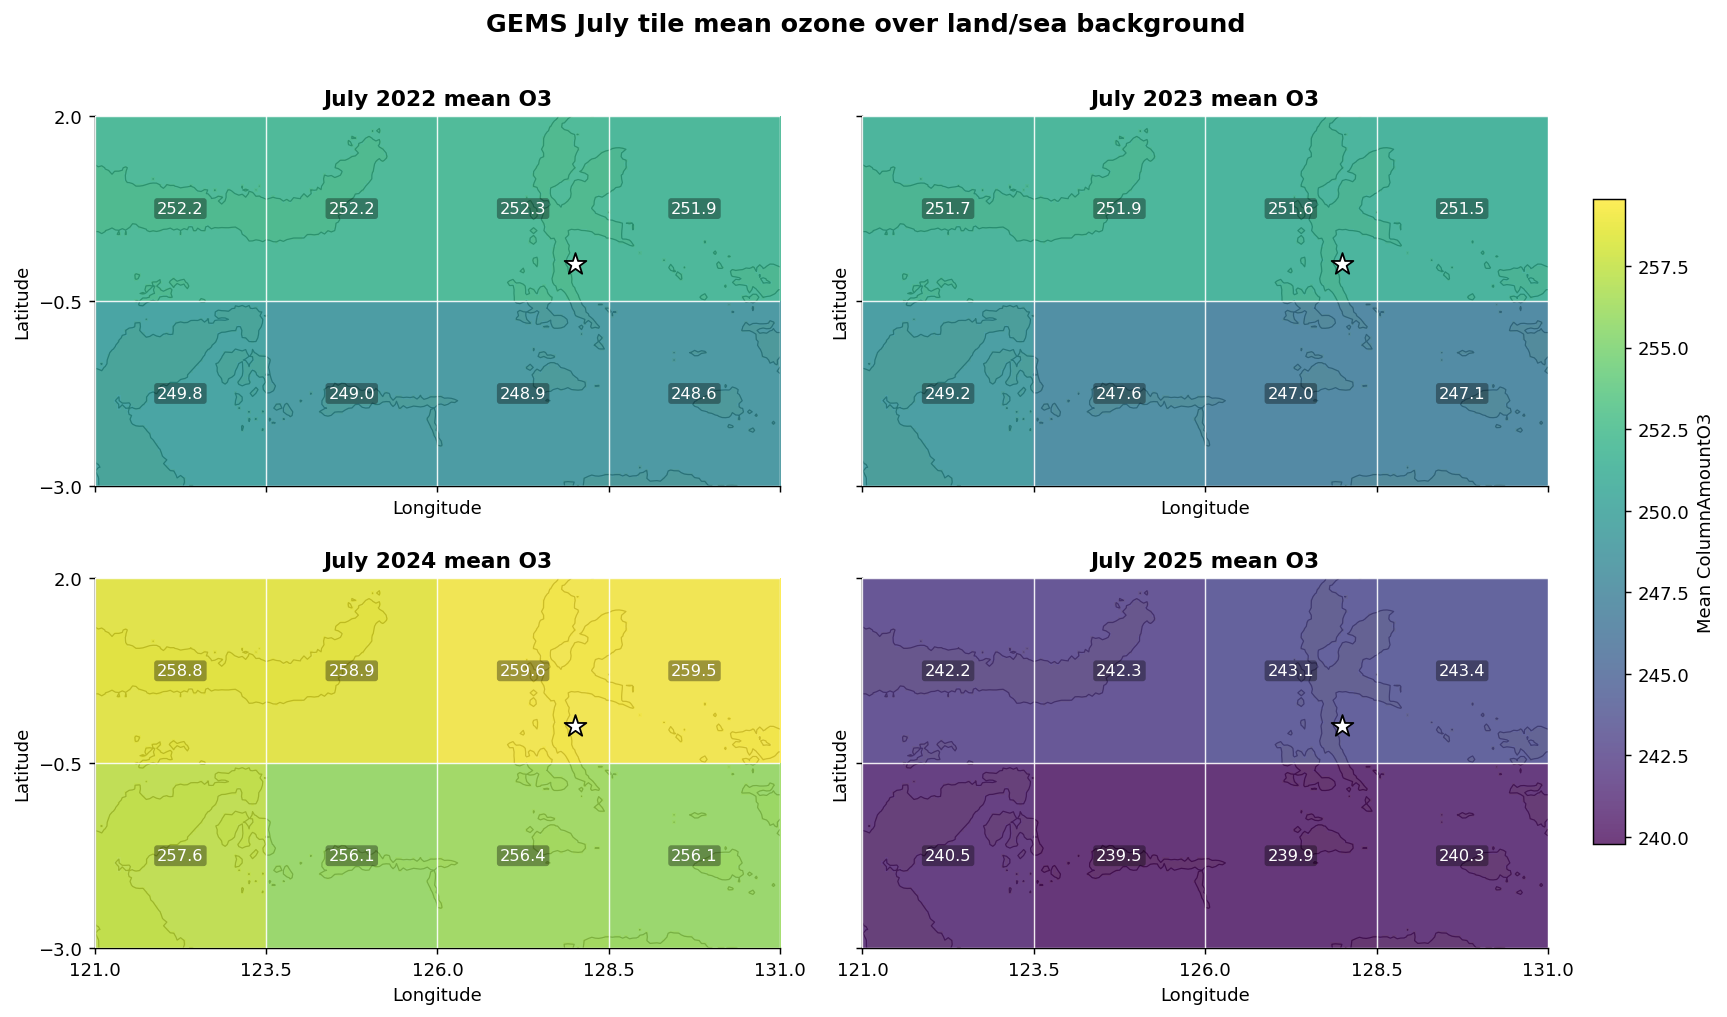

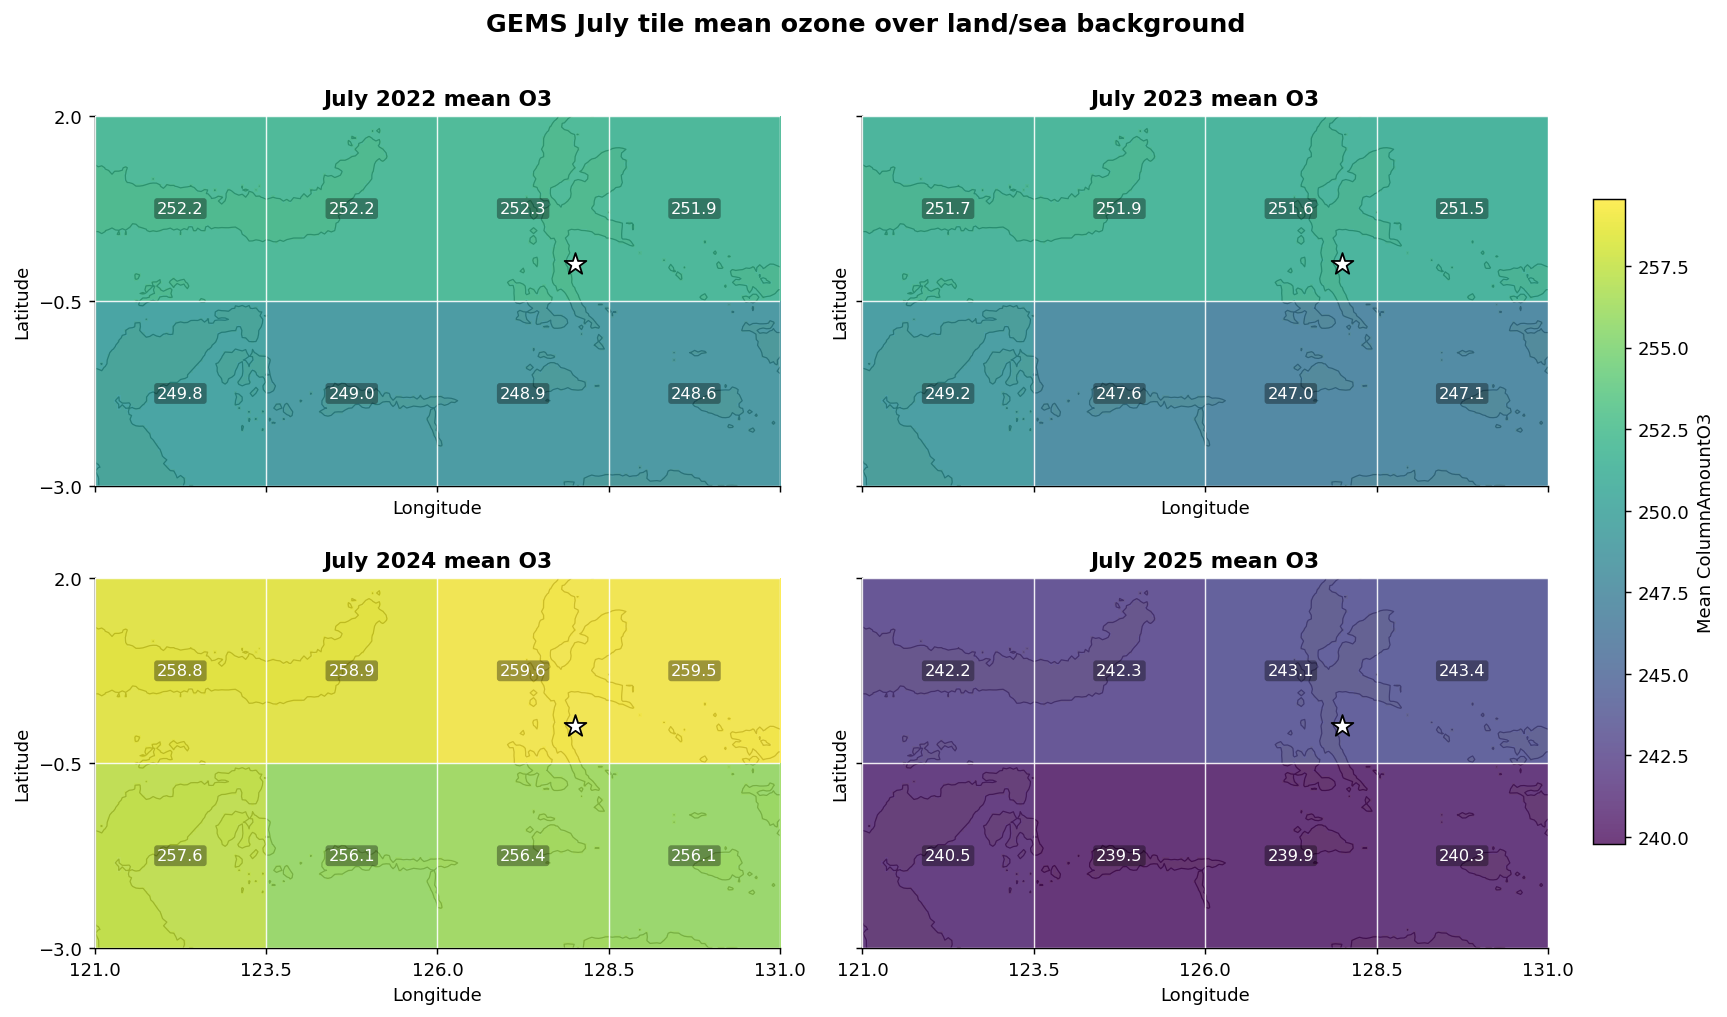

In [8]:
def plot_yearly_o3(tile_o3, elev):
    vmin = np.nanpercentile(tile_o3['mean_o3'], 2)
    vmax = np.nanpercentile(tile_o3['mean_o3'], 98)
    fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.0), sharex=True, sharey=True)
    axes = axes.ravel()
    last_im = None
    for ax, year in zip(axes, YEARS):
        year_df = tile_o3[tile_o3['year'] == year]
        mat = matrix_from_tiles(year_df, 'mean_o3')
        draw_land_sea_background(ax, elev)
        last_im = ax.imshow(
            mat,
            origin='lower',
            extent=[lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]],
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            alpha=0.76,
            aspect='auto',
            zorder=3,
        )
        annotate_tiles(ax, mat, fmt='{:.1f}')
        decorate_tile_axes(ax, f'July {year} mean O3')
    fig.suptitle('GEMS July tile mean ozone over land/sea background', fontsize=14, fontweight='bold')
    fig.subplots_adjust(left=0.07, right=0.88, bottom=0.08, top=0.88, wspace=0.12, hspace=0.25)
    cax = fig.add_axes([0.905, 0.18, 0.018, 0.62])
    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label('Mean ColumnAmountO3')
    out = OUT_DIR / f'o3_tile_mean_by_year_lat-3to2_lon121to131_{NY}x{NX}_{SOURCE_MODE}.png'
    fig.savefig(out, bbox_inches='tight')
    print('saved:', out)
    return fig

plot_yearly_o3(tile_o3, elev)

In [9]:

def compute_tile_trends(tile_o3):
    rows = []
    for (ty, tx), g in tile_o3.groupby(['tile_y', 'tile_x']):
        g = g.sort_values('year')
        years = g['year'].to_numpy(dtype=float)
        y = g['mean_o3'].to_numpy(dtype=float)
        ok = np.isfinite(years) & np.isfinite(y)
        if ok.sum() >= 2:
            fit = stats.linregress(years[ok], y[ok])
            slope = fit.slope
            intercept = fit.intercept
            pvalue = fit.pvalue
            rvalue = fit.rvalue
        else:
            slope = intercept = pvalue = rvalue = np.nan
        y2022 = g.loc[g['year'] == 2022, 'mean_o3']
        y2025 = g.loc[g['year'] == 2025, 'mean_o3']
        rows.append({
            'tile_y': int(ty),
            'tile_x': int(tx),
            'tile_id': int(ty) * NX + int(tx),
            'tile_lat_center': lat_centers[int(ty)],
            'tile_lon_center': lon_centers[int(tx)],
            'slope_o3_per_year': slope,
            'intercept': intercept,
            'pvalue': pvalue,
            'rvalue': rvalue,
            'delta_2025_minus_2022': (float(y2025.iloc[0]) - float(y2022.iloc[0])) if len(y2022) and len(y2025) else np.nan,
        })
    trends = pd.DataFrame(rows)
    return trends.merge(etopo_summary, on=['tile_y', 'tile_x', 'tile_id', 'tile_lat_center', 'tile_lon_center'], how='left')

trends = compute_tile_trends(tile_o3)
trend_csv = OUT_DIR / f'o3_tile_trend_with_etopo_lat-3to2_lon121to131_{NY}x{NX}_{SOURCE_MODE}.csv'
trends.round(6).to_csv(trend_csv, index=False)
print('saved:', trend_csv)
display(trends)


saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/o3_tile_trend_with_etopo_lat-3to2_lon121to131_2x4_pickle_grid.csv


,tile_y,tile_x,tile_id,tile_lat_center,tile_lon_center,slope_o3_per_year,intercept,pvalue,rvalue,delta_2025_minus_2022,...,tile_lon_min,tile_lon_max,n_etopo,mean_topobathy_m,median_topobathy_m,min_topobathy_m,max_topobathy_m,land_fraction,mean_land_elevation_m,max_land_elevation_m
0,0,0,0,-1.75,122.25,-1.959509,4214.361564,0.638182,-0.361818,-9.334999,...,121.0,123.5,2500,-393.539405,-32.0000,-4701.0,2518.7617,0.4424,525.572774,2518.7617
1,0,1,1,-1.75,124.75,-1.981445,4257.497580,0.622926,-0.377074,-9.449730,...,123.5,126.0,2500,-2426.571018,-2394.5000,-6001.0,1188.8893,0.0716,224.276290,1188.8893
2,0,2,2,-1.75,127.25,-1.741578,3772.130601,0.668468,-0.331532,-8.957459,...,126.0,128.5,2500,-2077.056599,-2170.5000,-5500.0,1823.3395,0.0908,240.754916,1823.3395
3,0,3,3,-1.75,129.75,-1.597009,3479.580102,0.683434,-0.316566,-8.332284,...,128.5,131.0,2500,-633.459760,-489.5000,-3275.0,1256.0304,0.1072,128.088057,1256.0304
4,1,0,4,0.75,122.25,-2.276035,4856.796494,0.568800,-0.431200,-9.954922,...,121.0,123.5,2500,-1380.381487,-1284.9025,-5602.0,1988.7983,0.2604,357.130480,1988.7983
5,1,1,5,0.75,124.75,-2.263827,4832.163924,0.573277,-0.426723,-9.898213,...,123.5,126.0,2500,-1948.008153,-2108.0000,-5662.0,1547.0657,0.1632,445.342409,1547.0657
6,1,2,6,0.75,127.25,-1.953032,4203.606884,0.625568,-0.374432,-9.162424,...,126.0,128.5,2500,-1074.770077,-953.0000,-3706.0,1186.8988,0.2212,245.668389,1186.8988
7,1,3,7,0.75,129.75,-1.741073,3774.654884,0.657811,-0.342189,-8.495820,...,128.5,131.0,2500,-1788.315366,-1277.5000,-5076.0,826.6312,0.0712,167.339196,826.6312


saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/o3_tile_trend_lat-3to2_lon121to131_2x4_pickle_grid.png


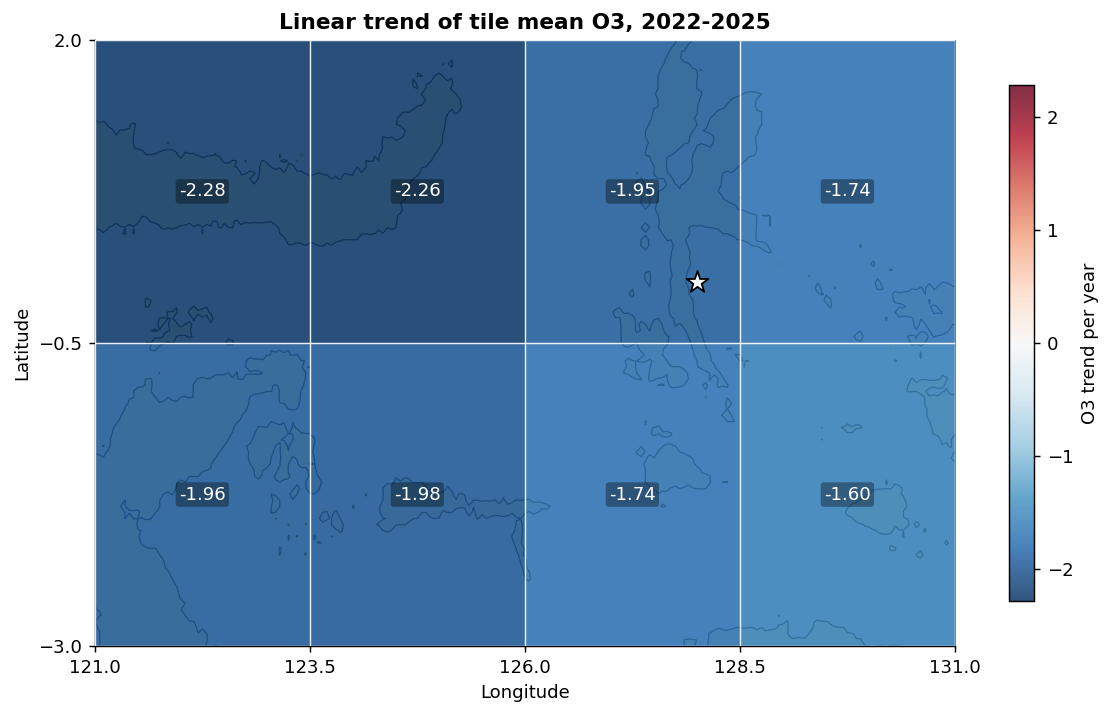

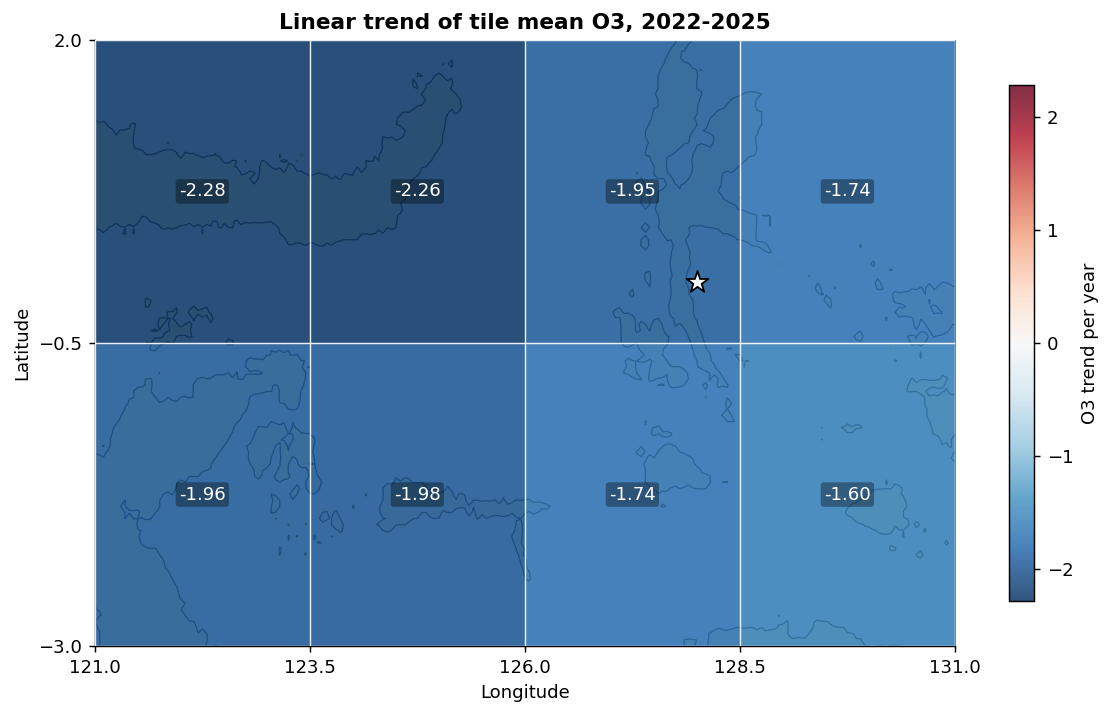

In [10]:

def plot_o3_trend(trends, elev):
    mat = matrix_from_tiles(trends, 'slope_o3_per_year')
    max_abs = np.nanmax(np.abs(mat))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0
    fig, ax = plt.subplots(figsize=(9.2, 5.6))
    draw_land_sea_background(ax, elev)
    im = ax.imshow(
        mat,
        origin='lower',
        extent=[lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]],
        cmap='RdBu_r',
        vmin=-max_abs,
        vmax=max_abs,
        alpha=0.82,
        aspect='auto',
        zorder=3,
    )
    annotate_tiles(ax, mat, fmt='{:+.2f}', fontsize=10)
    decorate_tile_axes(ax, 'Linear trend of tile mean O3, 2022-2025')
    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label('O3 trend per year')
    fig.tight_layout()
    out = OUT_DIR / f'o3_tile_trend_lat-3to2_lon121to131_{NY}x{NX}_{SOURCE_MODE}.png'
    fig.savefig(out, bbox_inches='tight')
    print('saved:', out)
    return fig

plot_o3_trend(trends, elev)


saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/etopo_relief_tile_context_lat-3to2_lon121to131_2x4.png


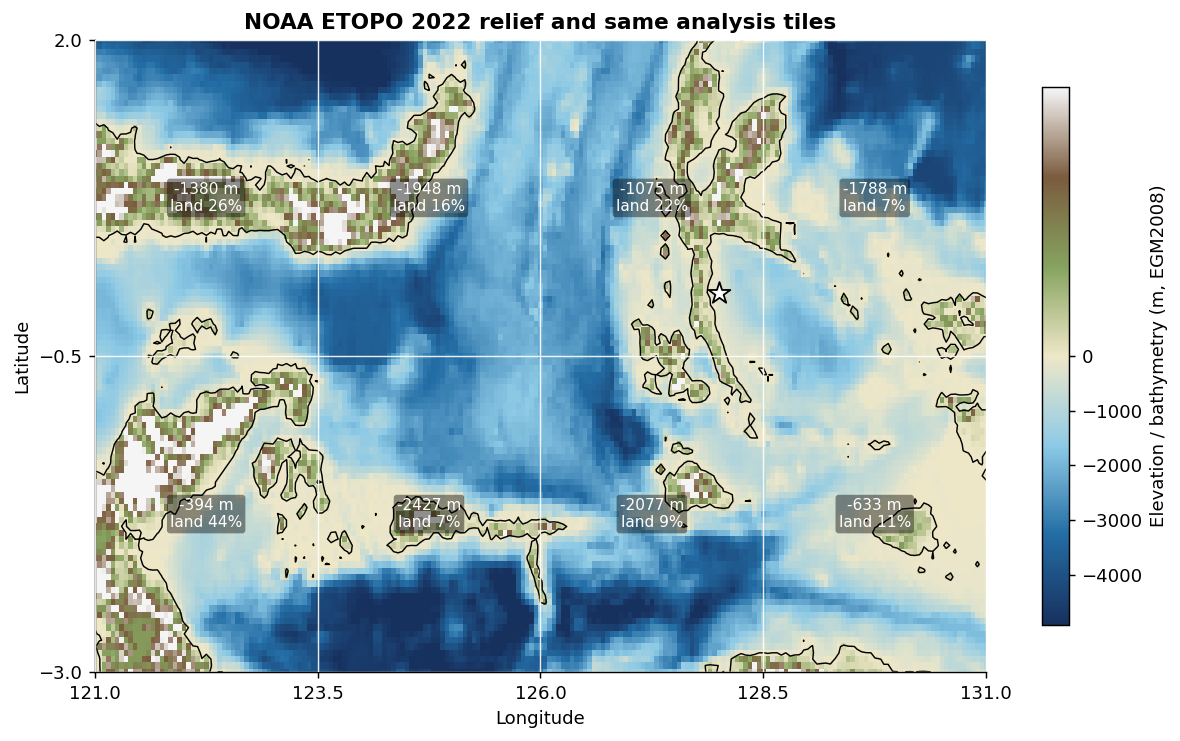

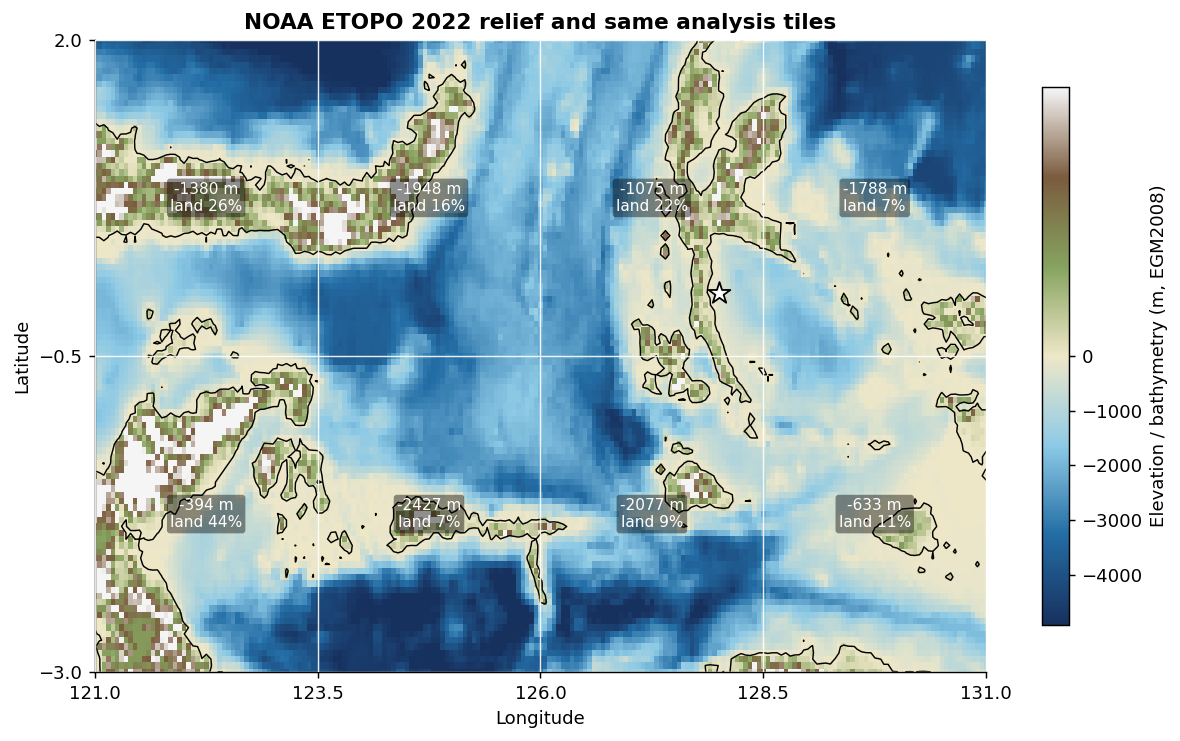

In [11]:

def plot_etopo_context(elev, etopo_summary):
    lon2d, lat2d, z = etopo_grid(elev)
    vmin = np.nanpercentile(z, 2)
    vmax = np.nanpercentile(z, 98)
    cmap = LinearSegmentedColormap.from_list(
        'topobathy_local',
        ['#17315f', '#236da5', '#8ecae6', '#eee7c8', '#86a35f', '#7b5b3e', '#f5f5f5'],
        N=256,
    )
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(1, vmax))

    fig, ax = plt.subplots(figsize=(9.5, 5.8))
    im = ax.pcolormesh(lon2d, lat2d, z, cmap=cmap, norm=norm, shading='nearest')
    ax.contour(lon2d, lat2d, z, levels=[0], colors='black', linewidths=0.8)
    decorate_tile_axes(ax, 'NOAA ETOPO 2022 relief and same analysis tiles')
    for row in etopo_summary.itertuples(index=False):
        label = f'{row.mean_topobathy_m:.0f} m\nland {100*row.land_fraction:.0f}%'
        ax.text(
            row.tile_lon_center,
            row.tile_lat_center,
            label,
            ha='center', va='center', fontsize=8.5, color='white', zorder=10,
            bbox=dict(boxstyle='round,pad=0.2', facecolor=(0, 0, 0, 0.42), edgecolor='none'),
        )
    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label('Elevation / bathymetry (m, EGM2008)')
    fig.tight_layout()
    out = OUT_DIR / f'etopo_relief_tile_context_lat-3to2_lon121to131_{NY}x{NX}.png'
    fig.savefig(out, bbox_inches='tight')
    print('saved:', out)
    return fig

plot_etopo_context(elev, etopo_summary)


saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/etopo_tile_mean_and_land_fraction_lat-3to2_lon121to131_2x4.png


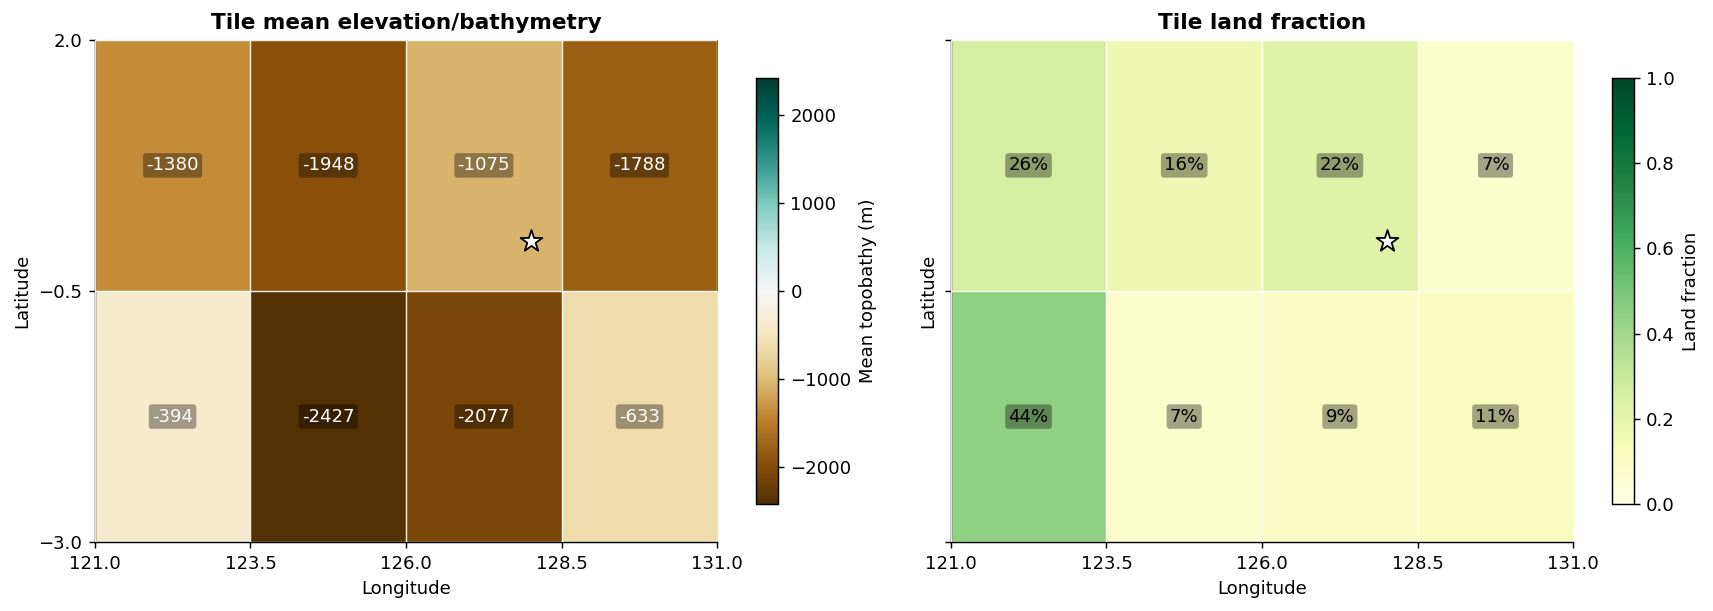

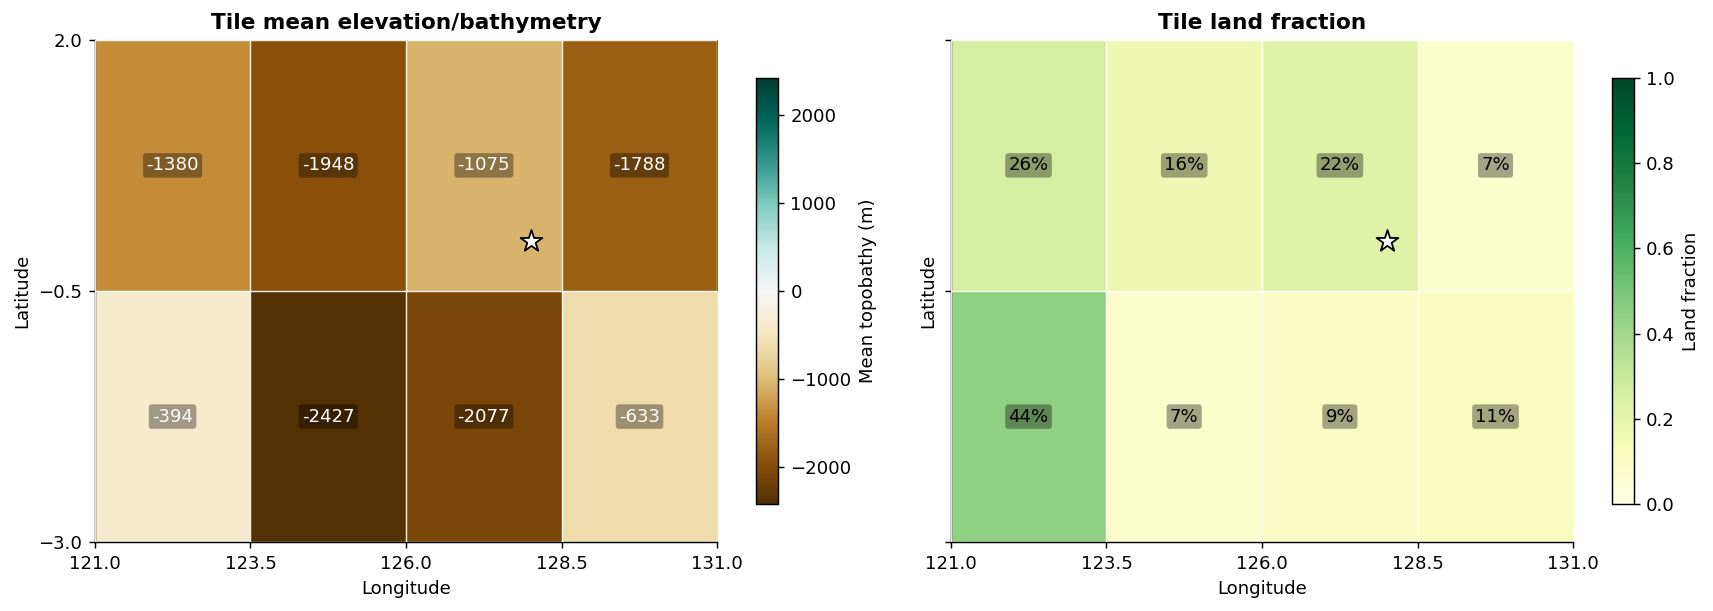

In [12]:

def plot_etopo_tile_summaries(etopo_summary):
    mean_z = matrix_from_tiles(etopo_summary, 'mean_topobathy_m')
    land_frac = matrix_from_tiles(etopo_summary, 'land_fraction')
    max_abs = np.nanmax(np.abs(mean_z))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True, sharey=True)
    im0 = axes[0].imshow(mean_z, origin='lower', extent=[lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]], cmap='BrBG', vmin=-max_abs, vmax=max_abs, aspect='auto')
    annotate_tiles(axes[0], mean_z, fmt='{:.0f}', fontsize=10)
    decorate_tile_axes(axes[0], 'Tile mean elevation/bathymetry')
    cb0 = fig.colorbar(im0, ax=axes[0], shrink=0.85)
    cb0.set_label('Mean topobathy (m)')

    im1 = axes[1].imshow(land_frac, origin='lower', extent=[lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]], cmap='YlGn', vmin=0, vmax=1, aspect='auto')
    annotate_tiles(axes[1], 100 * land_frac, fmt='{:.0f}%', color='black', fontsize=10)
    decorate_tile_axes(axes[1], 'Tile land fraction')
    cb1 = fig.colorbar(im1, ax=axes[1], shrink=0.85)
    cb1.set_label('Land fraction')

    fig.tight_layout()
    out = OUT_DIR / f'etopo_tile_mean_and_land_fraction_lat-3to2_lon121to131_{NY}x{NX}.png'
    fig.savefig(out, bbox_inches='tight')
    print('saved:', out)
    return fig

plot_etopo_tile_summaries(etopo_summary)


saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/o3_trend_vs_terrain_lat-3to2_lon121to131_2x4_pickle_grid.png


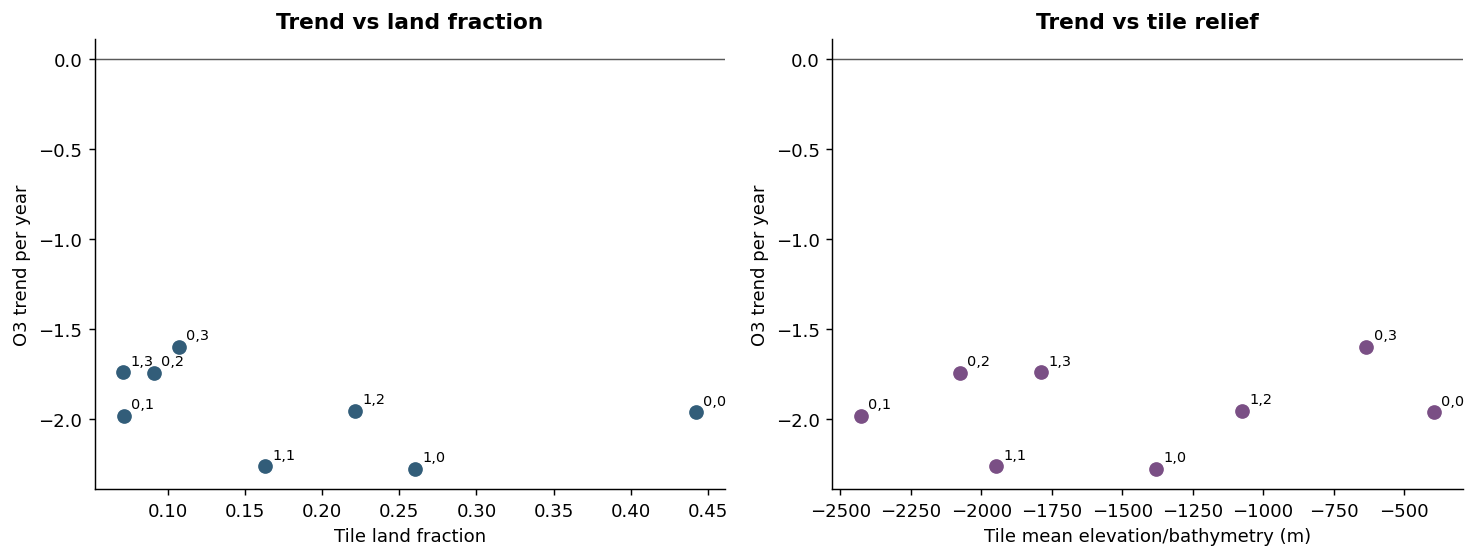

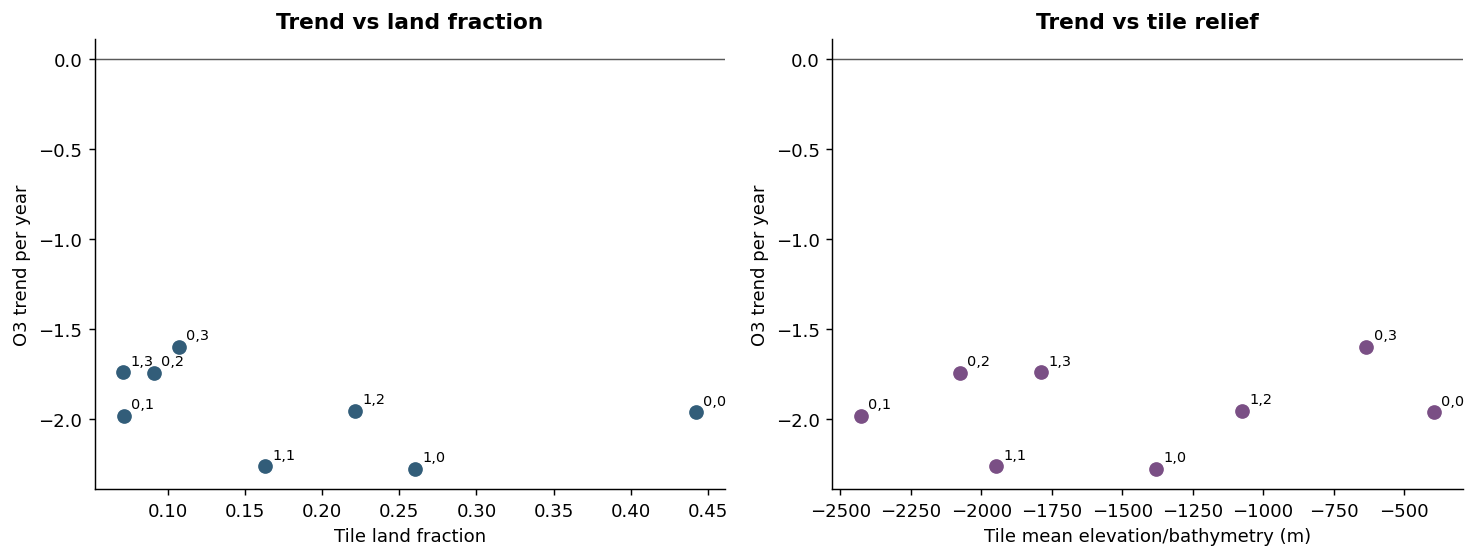

In [13]:

def plot_trend_vs_terrain(trends):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    axes[0].scatter(trends['land_fraction'], trends['slope_o3_per_year'], s=80, color='#325d79', edgecolor='white', linewidth=0.8)
    axes[0].set_xlabel('Tile land fraction')
    axes[0].set_ylabel('O3 trend per year')
    axes[0].set_title('Trend vs land fraction')
    axes[0].axhline(0, color='0.35', lw=0.8)

    axes[1].scatter(trends['mean_topobathy_m'], trends['slope_o3_per_year'], s=80, color='#7a4f85', edgecolor='white', linewidth=0.8)
    axes[1].set_xlabel('Tile mean elevation/bathymetry (m)')
    axes[1].set_ylabel('O3 trend per year')
    axes[1].set_title('Trend vs tile relief')
    axes[1].axhline(0, color='0.35', lw=0.8)

    for ax in axes:
        for row in trends.itertuples(index=False):
            x = row.land_fraction if ax is axes[0] else row.mean_topobathy_m
            ax.annotate(f'{int(row.tile_y)},{int(row.tile_x)}', (x, row.slope_o3_per_year), xytext=(4, 4), textcoords='offset points', fontsize=8)
    fig.tight_layout()
    out = OUT_DIR / f'o3_trend_vs_terrain_lat-3to2_lon121to131_{NY}x{NX}_{SOURCE_MODE}.png'
    fig.savefig(out, bbox_inches='tight')
    print('saved:', out)
    return fig

plot_trend_vs_terrain(trends)


In [14]:

# Compact tables for interpretation.
wide_o3 = tile_o3.pivot_table(index=['tile_y', 'tile_x'], columns='year', values='mean_o3').reset_index()
wide_o3 = wide_o3.merge(
    trends[['tile_y', 'tile_x', 'slope_o3_per_year', 'delta_2025_minus_2022', 'land_fraction', 'mean_topobathy_m', 'mean_land_elevation_m']],
    on=['tile_y', 'tile_x'],
    how='left',
)
display(wide_o3.round(3))

wide_csv = OUT_DIR / f'o3_mean_wide_with_terrain_lat-3to2_lon121to131_{NY}x{NX}_{SOURCE_MODE}.csv'
wide_o3.round(6).to_csv(wide_csv, index=False)
print('saved:', wide_csv)


,tile_y,tile_x,2022,2023,2024,2025,slope_o3_per_year,delta_2025_minus_2022,land_fraction,mean_topobathy_m,mean_land_elevation_m
0,0,0,249.848,249.205,257.615,240.514,-1.960,-9.335,0.442,-393.539,525.573
1,0,1,248.995,247.552,256.087,239.545,-1.981,-9.450,0.072,-2426.571,224.276
2,0,2,248.881,246.964,256.420,239.923,-1.742,-8.957,0.091,-2077.057,240.755
3,0,3,248.600,247.117,256.144,240.268,-1.597,-8.332,0.107,-633.460,128.088
4,1,0,252.201,251.704,258.808,242.246,-2.276,-9.955,0.260,-1380.381,357.130
5,1,1,252.172,251.870,258.926,242.273,-2.264,-9.898,0.163,-1948.008,445.342
6,1,2,252.278,251.618,259.575,243.116,-1.953,-9.162,0.221,-1074.770,245.668
7,1,3,251.944,251.451,259.528,243.448,-1.741,-8.496,0.071,-1788.315,167.339


saved: /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/pure_space/tile_o3_elevation_outputs/o3_mean_wide_with_terrain_lat-3to2_lon121to131_2x4_pickle_grid.csv
